### Introduction to Data Science – Lecture 8 – Practical Data Visualization
*COMP 5360 / MATH 4100, University of Utah, http://datasciencecourse.net/*

Some announcements / notes:

* We are finishing Lecture 7 first, starting with the grouping functionalities
* Next lecture will be slides-based, no notebook to download ahead of time (slides uploaded *after* class)
* Please remember to turn in only your final Jupyter notebook (so the TAs don't have to go searching for which one you meant to grade)

In this lecture, we'll cover some of the nitty-gritty details of how to create visualizations in Python. We will take a step back and talk about visualization design and methods in the next lecture. 

The Python data visualization environment is, to put it politely, *plentiful*. A previous instructor felt this comic was apt: 


![](standards.png)

### Matplotlib & Extensions

 * [Matplotlib](https://matplotlib.org/) - the big dog
 * [Pandas Visualization](https://pandas.pydata.org/pandas-docs/stable/visualization.html) - based on Matplotlib
 * [Seaborn](https://seaborn.pydata.org/) - based on Matplotlib, higher-level
 * [ggplot](https://ggplot2.tidyverse.org/) - based on the popular R plotting library, some similarites, uses Matplotlib.
 
These tools generally can be used to create figures independent of Jupyter. 
 
### Web-based Vis tools

 * [Plotly](https://plot.ly/python/)
 * [Altair](https://github.com/altair-viz/altair), based on [Vega](https://vega.github.io/vega/) 
 * [PdVega](https://altair-viz.github.io/pdvega/), based on Vega, integrated with pandas dataframes.
 * [Bokeh](https://bokeh.pydata.org/en/latest/)
 
 
These tools mostly rely on Jupyter running in your browser and use a JavaScript based language in the back-end. 

As of January 2026, Plotly and Altair continue to gain ground for more advanced, interactive visualization and Jupyter-embedded contenders using [AnyWidget](https://anywidget.dev/) are becoming more prevalent.

There are also some domain specific libraries, e.g., for maps and for networks, that we will cover at a later point. 
 
 
There are also [many](https://www.dataquest.io/blog/python-data-visualization-libraries/) [blog](https://codeburst.io/overview-of-python-data-visualization-tools-e32e1f716d10) [posts](https://lisacharlotterost.github.io/2016/05/17/one-chart-code/) [comparing](https://blog.modeanalytics.com/python-data-visualization-libraries/) various data visualization libraries.

Generally speaking, there are 
 * **charting libraries** that have pre-made charts, and 
 * **drawing libraries** that allow you to freely express anything you can imagine. 
 
We will mainly cover the former, but as visualization researchers we typically rely on tools that enable as much expressivity as possible, such as [D3](https://d3js.org/) or [WebGL](https://developer.mozilla.org/en-US/docs/Web/API/WebGL_API).

We will start of with basic Matplotlib, explore the build-in pandas library, and then look at some more advanced tools.

## Matplotlib

Matplotlib is a project started in 2002 and is inspired by MATLAB plotting. 

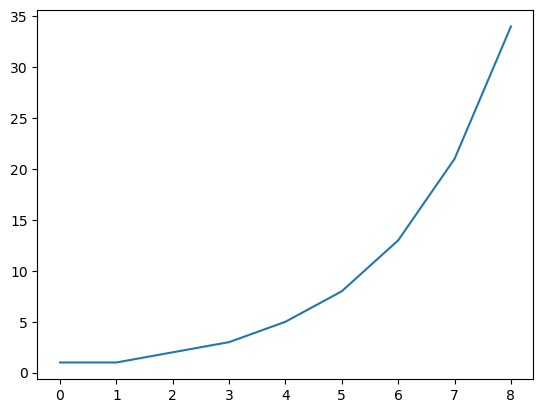

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# code after a % are ipython specific instructions, often referred to as "magic"s
# this command tells Jupyter/ipython that we want to create the visualizations
# inline in this notebook instead of as files to save. Note we still need a .show()
# to tell Jupyter and matplotlib to draw it.
%matplotlib inline

# an example data vector
fib_series = [1,1,2,3,5,8,13,21,34]

# here we run a simple plot command to create a line chart
plt.plot(fib_series)
plt.show()

The `.plot` command uses a [`figure`](https://matplotlib.org/api/_as_gen/matplotlib.figure.Figure.html#matplotlib.figure.Figure) to plot in. Note Figure is a matplotlib Class as we've discussed before in class. Thus, our calls create a Figure *object*. If no figure object has been defined, it will automatically create one. If there is already a figure object, it will plot to the latest figure object. 

Here we create a figure object manually: 

In [2]:
# we create a figure with size 10 by 10 inches
fig = plt.figure(figsize=(10, 10))

<Figure size 1000x1000 with 0 Axes>

The figure by itself doesn't plot anyhing. We have to add a [`subplot`](https://matplotlib.org/api/_as_gen/matplotlib.figure.Figure.html#matplotlib.figure.Figure.add_subplot) to it. 

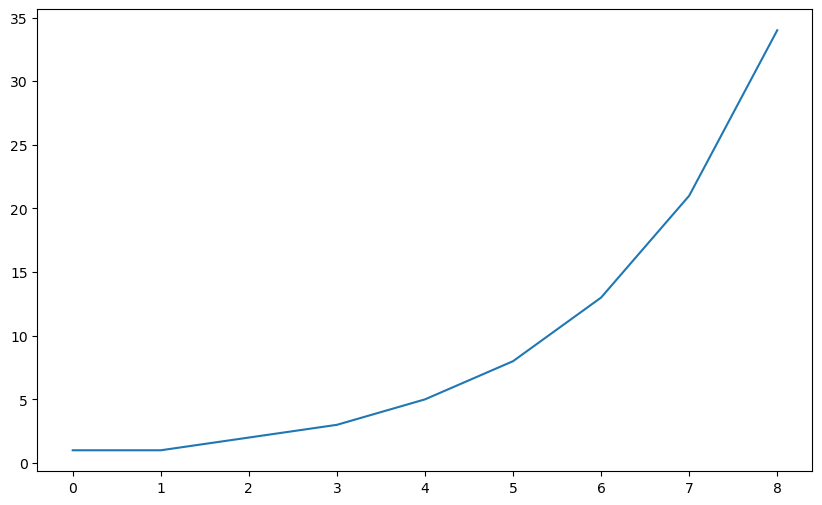

In [3]:
# figsize defines the size of the plot in inches - 10 wide by 6 high here. 
fig = plt.figure(figsize=(10, 6))
# add a suplot to a grid of 1x1, return the 1st figure
my_plot = fig.add_subplot(1,1,1)
# plotting a data array
my_plot.plot(fib_series)
plt.show()

Here we add a title and axis labels: 

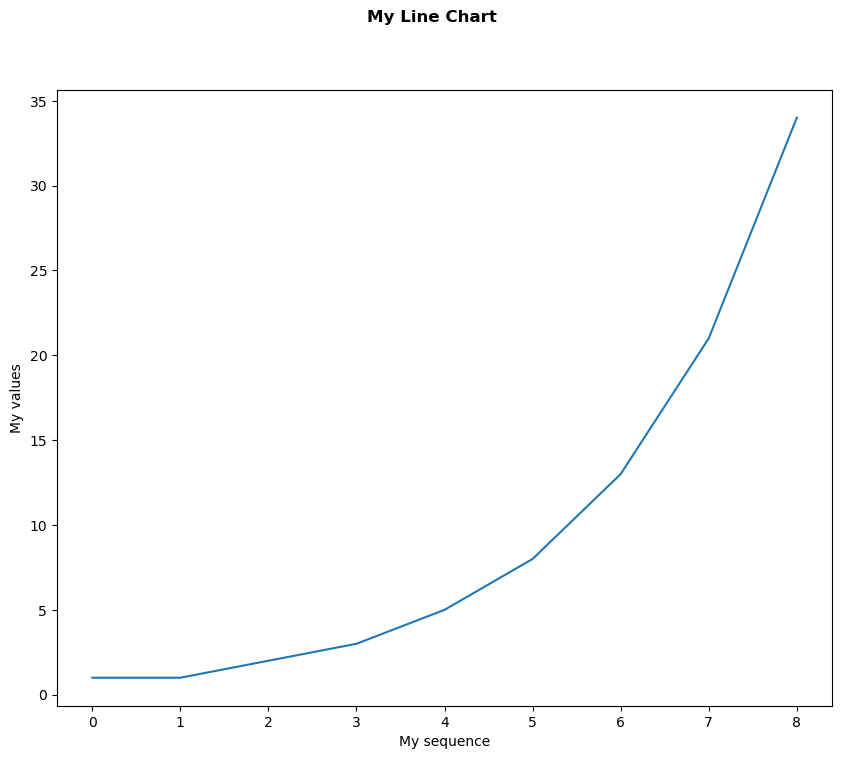

In [4]:
fig = plt.figure(figsize=(10, 8))
my_plot = fig.add_subplot(1,1,1)
fig.suptitle('My Line Chart', fontsize=12, fontweight='bold')
my_plot.set_xlabel("My sequence")
my_plot.set_ylabel("My values")
my_plot.plot(fib_series)
plt.show()

We can plot multiple line charts by calling plot multiple times on the same axis. (Note: These lines all use the same y-axis. Next time we will discuss avoiding using multiple y-axes.)

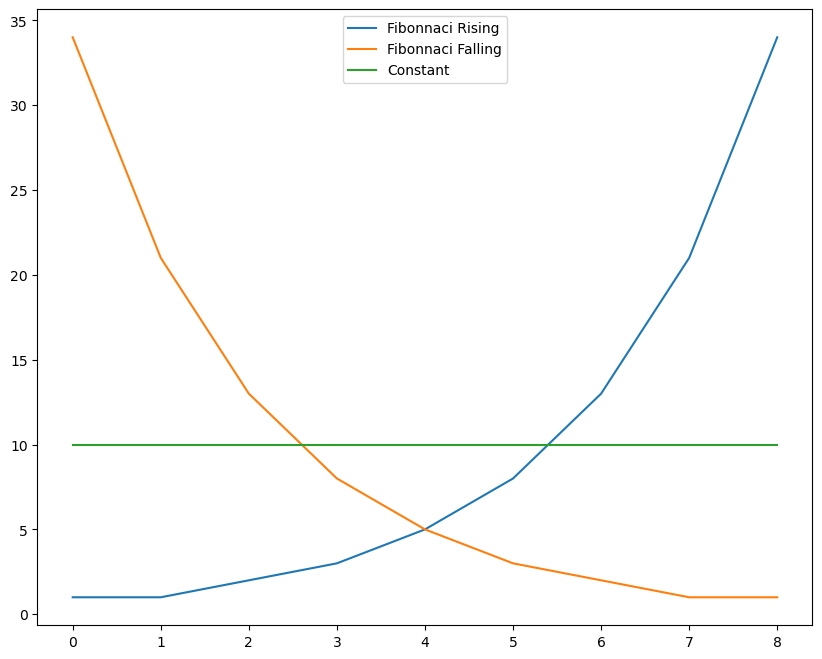

In [5]:
fig = plt.figure(figsize=(10, 8))
my_plot = fig.add_subplot(1,1,1)
fib_rising, = my_plot.plot(fib_series)
fib_falling, = my_plot.plot(fib_series[::-1])
constant, = my_plot.plot([10]*9)

# Here's how we create a legend
my_plot.legend((fib_rising, fib_falling, constant), ("Fibonnaci Rising", "Fibonnaci Falling", "Constant") )
plt.show()

Alternatively, we can also call the plot function with multiple data series. 

Note that here we have to specify both x and y values, the y values were implicit earlier.

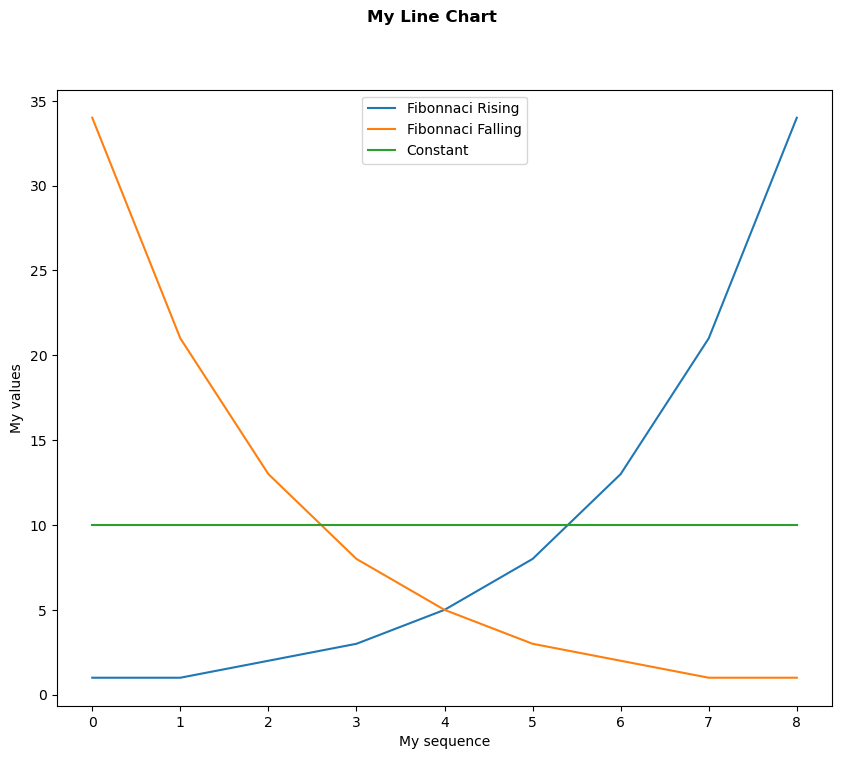

In [6]:
fig = plt.figure(figsize=(10, 8))
my_plot = fig.add_subplot(1,1,1)
fig.suptitle('My Line Chart', fontsize=12, fontweight='bold')
my_plot.set_xlabel("My sequence")
my_plot.set_ylabel("My values")
fib_rising, fib_falling, constant = my_plot.plot(range(9), fib_series, range(9), fib_series[::-1], range(9), [10]*9)
my_plot.legend((fib_rising, fib_falling, constant), ("Fibonnaci Rising", "Fibonnaci Falling", "Constant") )
plt.show()

Now let's create a figure with multiple subplots:

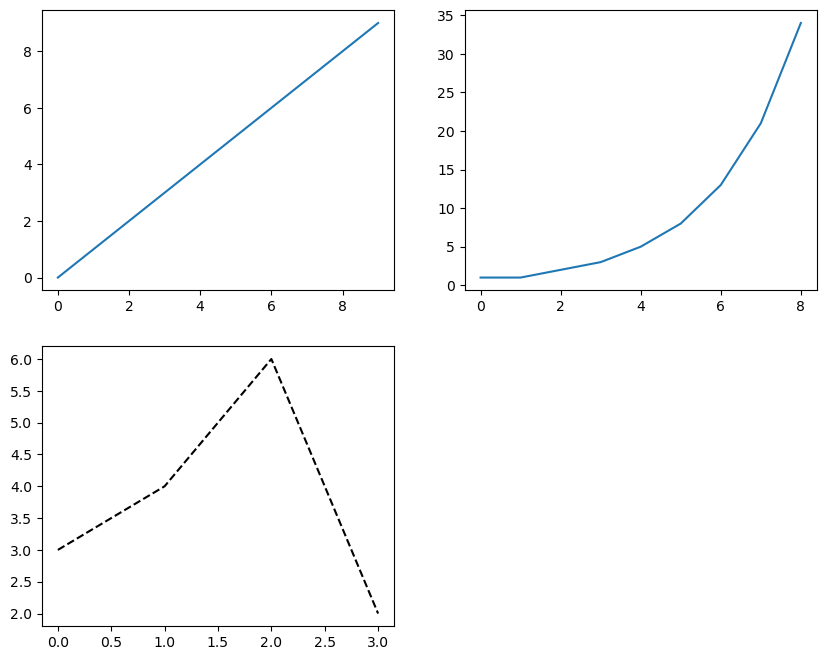

In [7]:
fig = plt.figure(figsize=(10, 8))

# create a subplot in a 2 by 2 grid, 
# return the subplot at position specified in third parameter
# these subplots are often called "axes"
sub_fig_1 = fig.add_subplot(2,2,1)
sub_fig_2 = fig.add_subplot(2,2,2)
sub_fig_3 = fig.add_subplot(2,2,3)

# this will plot to the last figure used
# you shouldn't do that but rather use explicit subplot references if you have them
# k-- is a style option for a black dashed line
plt.plot([3, 4, 6, 2], "k--")

# here is how we can plot explicitly to subfigures
sub_fig_1.plot(range(0,10))

sub_fig_2.plot(fib_series)
plt.show()

We can use the [`subplots`](https://matplotlib.org/api/_as_gen/matplotlib.figure.Figure.html?highlight=subplots#matplotlib.figure.Figure.subplots) shorthand to create multiple subplots that we can access form an array. 

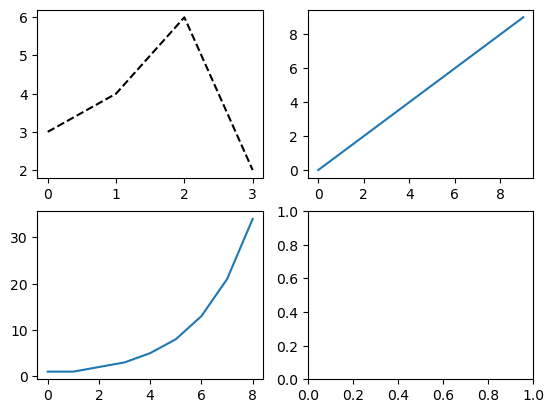

In [8]:
# using the variable axs for multiple Axes
fig, axs = plt.subplots(2, 2)

axs[0][0].plot([3, 4, 6, 2], "k--")
axs[0][1].plot(range(0,10))
axs[1][0].plot(fib_series)
plt.show()

Or we can use tuples to unpack the array: 

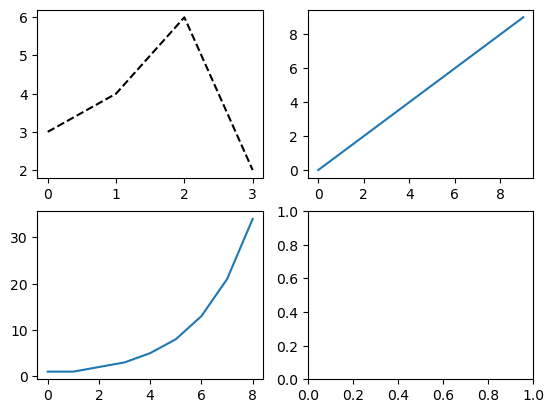

In [9]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)
ax1.plot([3, 4, 6, 2], "k--")
ax2.plot(range(0,10))
ax3.plot(fib_series)
plt.show()

### Try it!

Plot a line chart with the digits of your uID (similar to the upper left plot above) in a single figure with three subplots, arranged horizontally or vertically (your choice). Try different [linestyles](https://matplotlib.org/stable/gallery/lines_bars_and_markers/linestyles.html) and [mark styles](https://matplotlib.org/stable/gallery/lines_bars_and_markers/marker_reference.html) in each one. You can use the `linestyle` and `marker` keyword parameters or you can use the call with a format parameter (like the `k--` above) defined in the notes section of the [Plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) reference.

### More Charts

Next, we will create a couple of different visualization techniques: 

Visualizations for Correlations
 
 * [Scatterplot](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.scatter.html#matplotlib.pyplot.scatter)  
 
Visualizations for raw data, one dimension 
 * [Vertical Bar Chart](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.bar.html#matplotlib.pyplot.bar)
 * [Horizontal Bar Chart](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.barh.html#matplotlib.pyplot.barh)
 * [Pie Chart](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.pie.html#matplotlib.pyplot.pie)
 
Visualizations for distributions 
 * [Boxplot](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.boxplot.html#matplotlib.pyplot.boxplot)
 * [Histogram](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html?highlight=hist#matplotlib.pyplot.hist)
 * [Violin Plot](https://matplotlib.org/api/_as_gen/matplotlib.axes.Axes.violinplot.html)
 
 We'll discuss charts to use more next class, including some visual vocabularies, also available online here:
 * [Financial Times Visual Vocabulary](https://ft-interactive.github.io/visual-vocabulary/)
 * [Tableau Visual Vocabulary](https://www.tableau.com/solutions/gallery/visual-vocabulary)

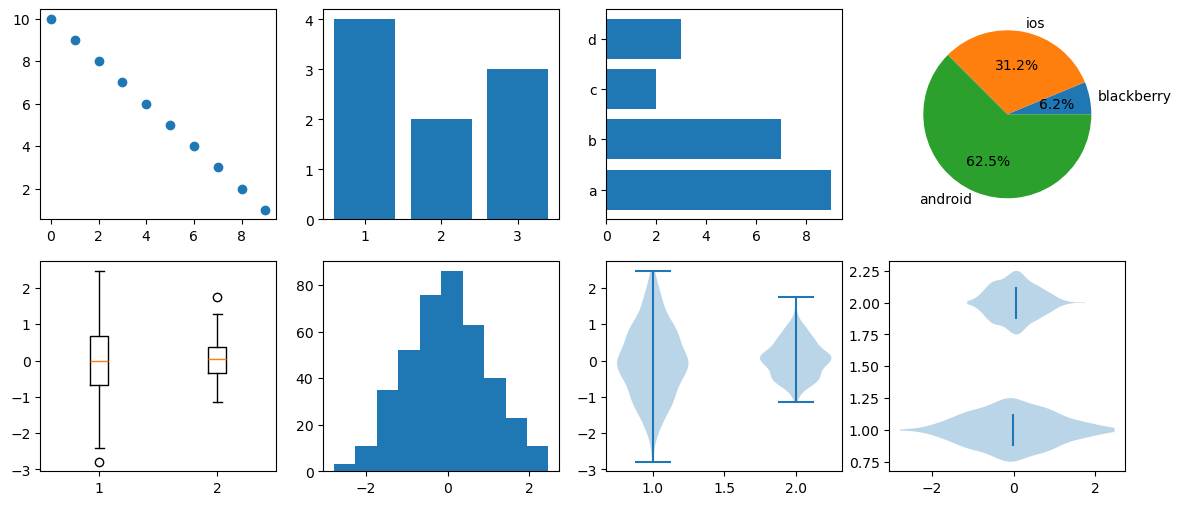

In [10]:
large_dist = np.random.randn(400)
small_dist = np.random.randn(400)*0.5


# a function because we'll reuse these later
def sample_figures():
    # define a figure with subfigures in 2 rows and 3 columns
    fig, subfigs = plt.subplots(2, 4, figsize=(14, 6))

    # Scatterplot. Pass two arrays for your x and y values.
    subfigs[0,0].scatter(range(0,10),range(10,0,-1))
    
    # Bar Chart. First array is x position, second is value (height) of data
    subfigs[0,1].bar([1, 2, 3], [4, 2, 3])
    
    # Horizontal bar chart. 
    # First array contains y positions (expressed as range), second contains data values (lengths of bars), 
    # tick_label is an array of labels
    subfigs[0,2].barh(range(0,4), [9, 7, 2, 3], tick_label=["a", "b", "c", "d"])
    
    # You can also do pie charts. First array is shares of total. 
    # labels in the same order of data. autopct defines how to format the numerical labels 
    # (here, one digit after comma)
    subfigs[0,3].pie([1, 5, 10], labels=["blackberry", "ios", "android"], autopct='%1.1f%%')
    
    # Box plots visualizing two distributions with 100 items each. 
    subfigs[1,0].boxplot([large_dist, small_dist])
    
    # A histogram visualizes a distribution. It takes one array, we can specify bins as second parameter 'bins'
    subfigs[1,1].hist(large_dist)
    
    # A violing plot also visualizes a distribution, using kernel density estimation.  
    subfigs[1,2].violinplot([large_dist, small_dist])
    
    # a cleaner, horizontal version of a violin plot
    subfigs[1,3].violinplot([large_dist, small_dist], showmeans=True,
        showextrema=False, vert=False)

    plt.show()

sample_figures()

### Heat Maps

Heat maps encoded matrix/tabular data using color. There are two ways to implement heatmaps in Matplotlib:

 * [pcolor](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pcolor.html)
 * [imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html)

imshow is used to display images (which are just matrices, where the pixels have a colorvalue). In practice, imshow and pcolor differ mainly in their coordinate system: the origin of imshow is at the top left (as is common for images), the origin of pcolor is at the bottom left.

For heatmaps, we need a [color map](https://matplotlib.org/tutorials/colors/colormaps.html). Matplotlib has many color maps baked in, including those from http://colorbrewer.org.

In [11]:
# just a helper function to create some 2D data based on a gaussian kernel.
def gkern(l=5, sig=1.):
    """
    creates gaussian kernel with side length l and a sigma of sig
    """
    ax = np.arange(-l // 2 + 1., l // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sig**2))
    return kernel / np.sum(kernel)

kernel = gkern(20, 5)

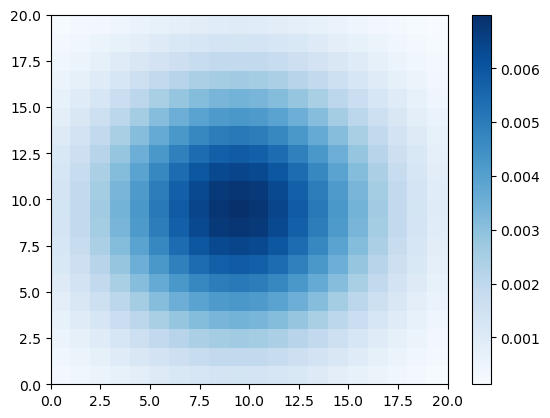

In [12]:
plt.style.use('default')
# select a blue color map
heatmap = plt.pcolor(kernel, cmap=plt.cm.Blues)
# plot the legend on the side
plt.colorbar(heatmap)
plt.show()

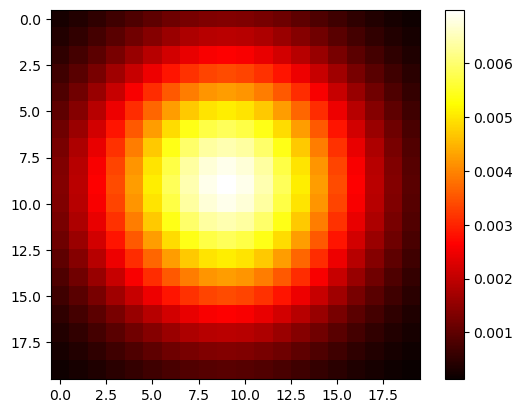

In [13]:
hm = plt.imshow(kernel, cmap='hot')
plt.colorbar(hm)
plt.show()

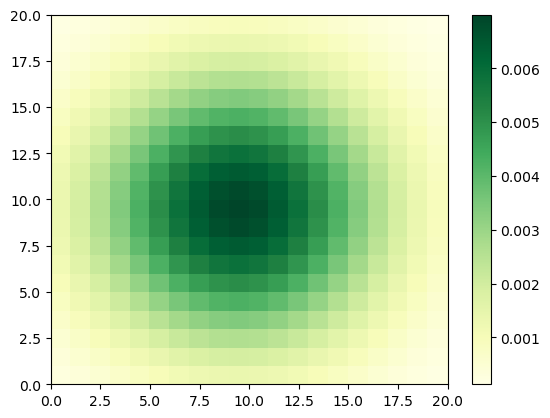

In [14]:
# a diverging color map from Color Brewer
heatmap = plt.pcolor(kernel, cmap=plt.cm.YlGn)
plt.colorbar(heatmap)
plt.show()

### Styling

Matplotlib has [different styles](https://matplotlib.org/devdocs/gallery/style_sheets/style_sheets_reference.html) that we can apply globally.

Here are a couple of examples:

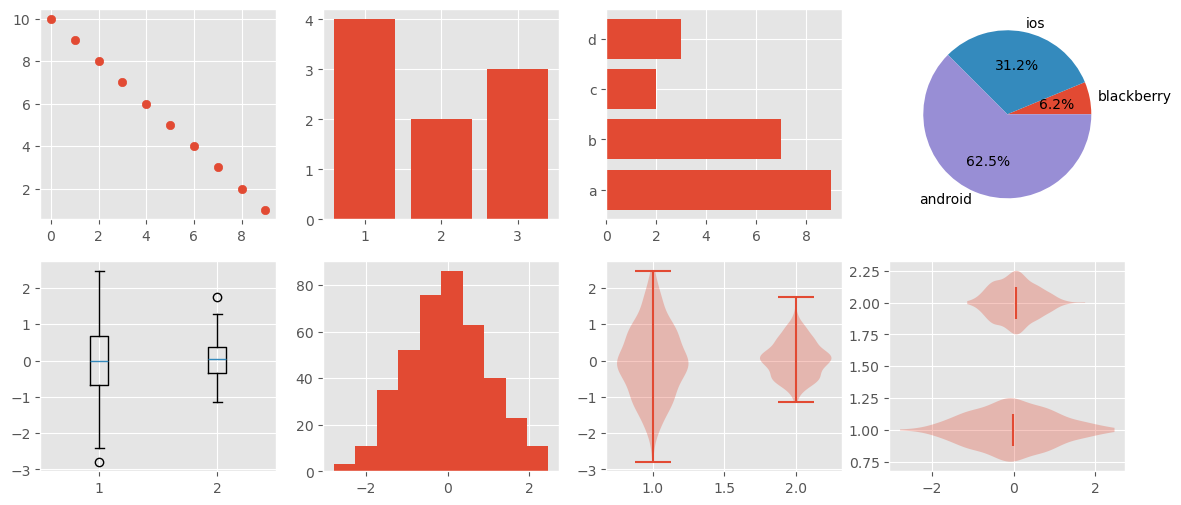

In [15]:
# ggplot style based on the popular R plotting library 
plt.style.use('ggplot')
sample_figures()

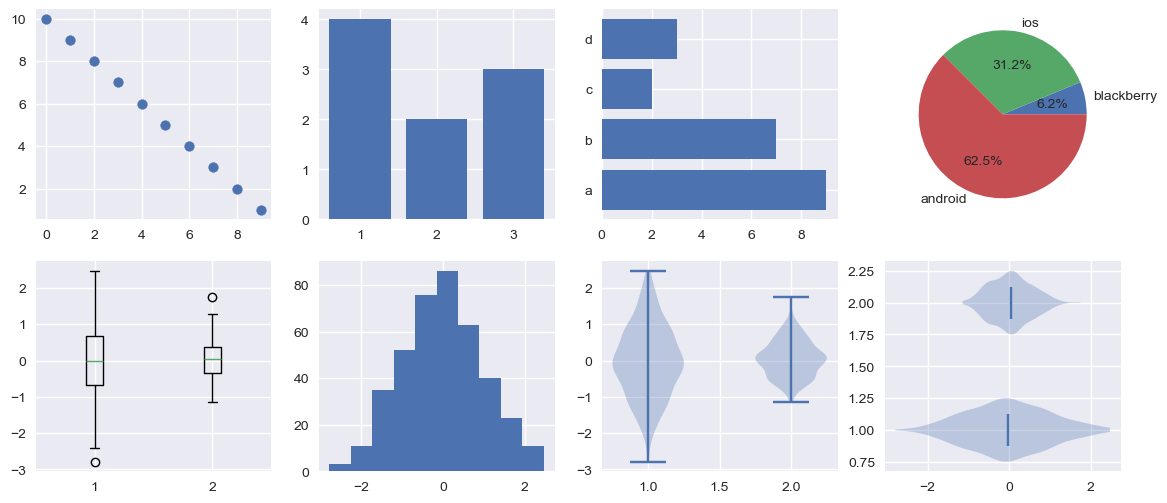

In [16]:
# style based on the v0.8 of the seaborn library, no longer kept current
plt.style.use('seaborn-v0_8')
# plt.style.use('seaborn')
sample_figures()

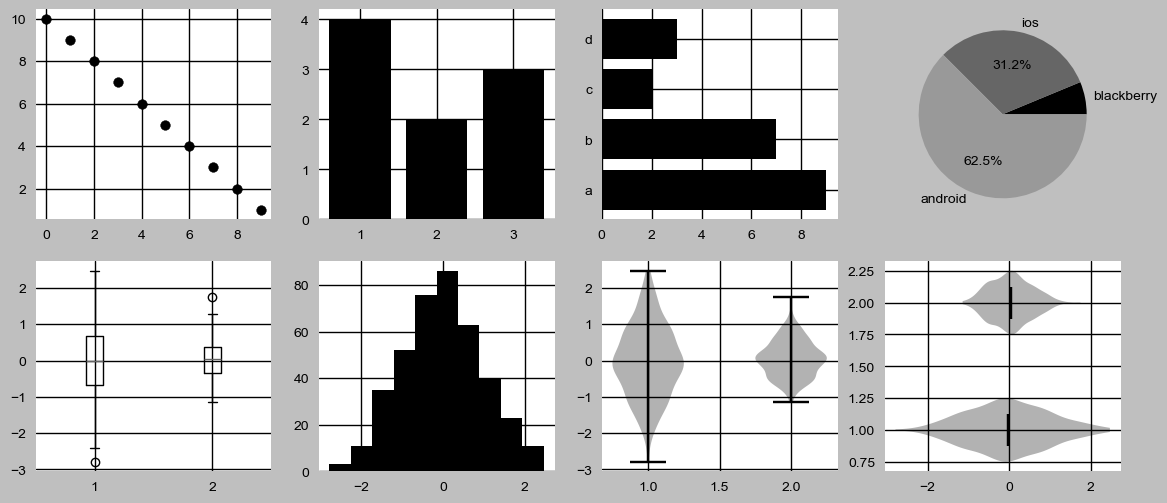

In [17]:
plt.style.use('grayscale')
sample_figures()

## Plotting with Pandas

Pandas has good [built-in plotting capabilities](https://pandas.pydata.org/docs/user_guide/visualization.html). We've seen some already in previous lectures and in the homeworks.

We're going to use the movies dataset to demonstrate plots and start of by reproducing some of the work you did for your homework: 

In [18]:
plt.style.use('ggplot')
pd_movies = pd.read_csv('movies.csv')
pd_movies.head()

,Unnamed: 0,title,year,length,budget,rating,votes,r1,r2,r3,...,r9,r10,mpaa,Action,Animation,Comedy,Drama,Documentary,Romance,Short
0,1,$,1971,121,NaN,6.4,348,4.5,4.5,4.5,...,4.5,4.5,NaN,0,0,1,1,0,0,0
1,2,$1000 a Touchdown,1939,71,NaN,6.0,20,0.0,14.5,4.5,...,4.5,14.5,NaN,0,0,1,0,0,0,0
2,3,$21 a Day Once a Month,1941,7,NaN,8.2,5,0.0,0.0,0.0,...,24.5,24.5,NaN,0,1,0,0,0,0,1
3,4,"$40,000",1996,70,NaN,8.2,6,14.5,0.0,0.0,...,34.5,45.5,NaN,0,0,1,0,0,0,0
4,5,"$50,000 Climax Show, The",1975,71,NaN,3.4,17,24.5,4.5,0.0,...,0.0,24.5,NaN,0,0,0,0,0,0,0


### Line Chart

In [19]:
# subset to major movies
major_movies = pd_movies[pd_movies['votes'] >= 500]
# show yearly number of moves
yearly_movies = major_movies["year"].value_counts().sort_index()

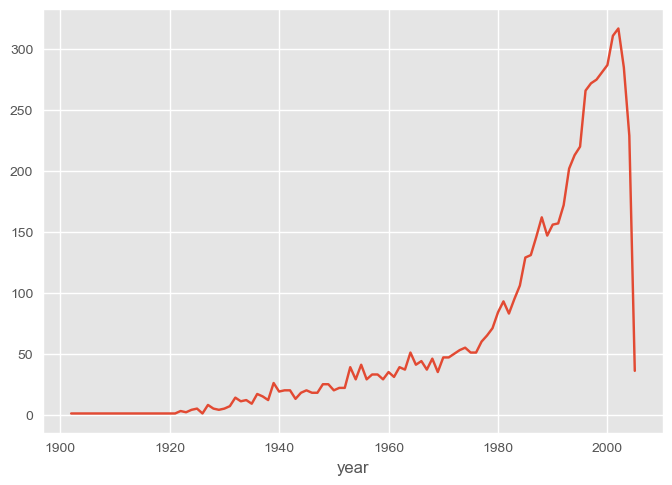

In [20]:
# you can also do this:
# yearly_movies.plot()
# or
# yearly_movies.plot(kind="line")
yearly_movies.plot.line()
plt.show()

In general, common charts can be done with `.plot.<kind>()` or `.plot(kind="<kind>")`

### Histogram

You can make a histogram with:

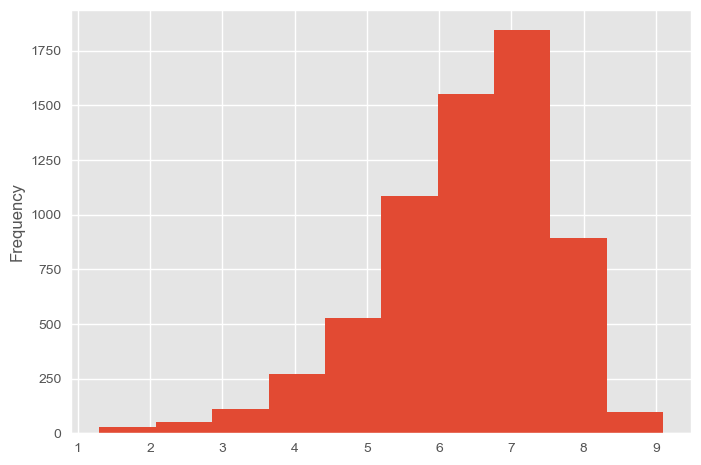

In [21]:
major_movies["rating"].plot.hist()
plt.show()

There are some legacy methods at accessing the column: 

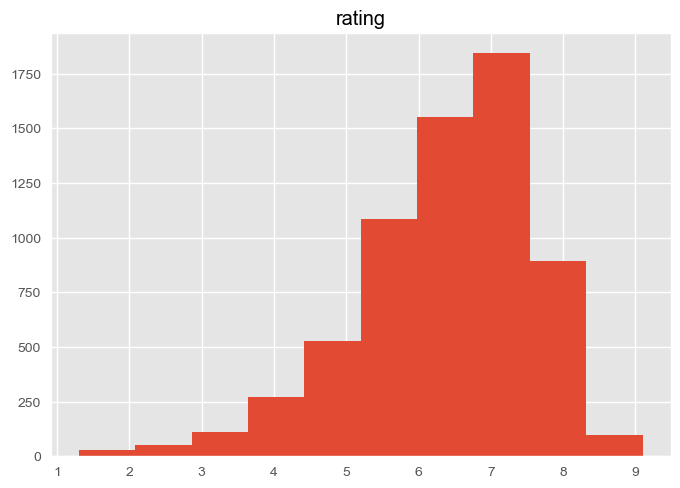

In [22]:
major_movies.hist(column="rating")
plt.show()

Let's load a dataset with multiple dimensions on the same scale, and plot it as histograms. 

In [23]:
penguins = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv')

# Clean dataset and put it in more similar size units for the following plots only
penguins_altered = penguins.copy()
penguins_altered = penguins_altered.dropna()
penguins_altered['body_mass_100g'] = penguins_altered['body_mass_g'] * 0.01
if 'body_mass_g' in penguins_altered.columns:
      penguins_altered = penguins_altered.drop(['body_mass_g'], axis=1)
penguins_altered

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,sex,body_mass_100g
0,Adelie,Torgersen,39.1,18.7,181.0,MALE,37.50
1,Adelie,Torgersen,39.5,17.4,186.0,FEMALE,38.00
2,Adelie,Torgersen,40.3,18.0,195.0,FEMALE,32.50
4,Adelie,Torgersen,36.7,19.3,193.0,FEMALE,34.50
5,Adelie,Torgersen,39.3,20.6,190.0,MALE,36.50
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,FEMALE,49.25
340,Gentoo,Biscoe,46.8,14.3,215.0,FEMALE,48.50
341,Gentoo,Biscoe,50.4,15.7,222.0,MALE,57.50
342,Gentoo,Biscoe,45.2,14.8,212.0,FEMALE,52.00


Allison Horst's illustration of the penguin types from [https://github.com/allisonhorst/palmerpenguins](https://github.com/allisonhorst/palmerpenguins):

<img src="https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png?raw=true" width=500 /><img src="https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/culmen_depth.png?raw=true" width=400 />

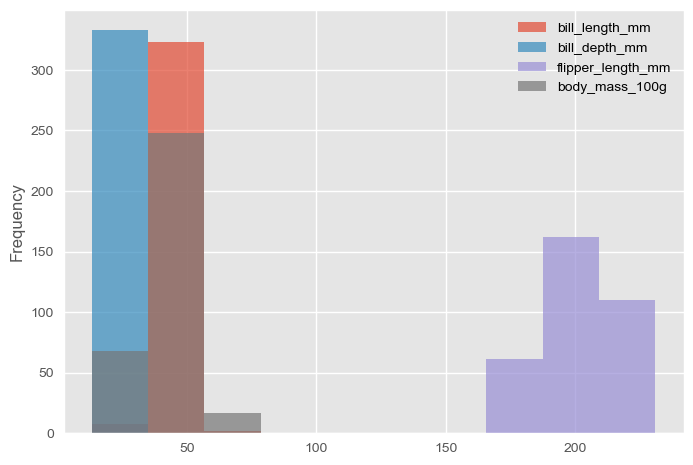

In [24]:
penguins_altered.plot.hist(alpha=0.7)
plt.show()

We can also plot KDEs: 

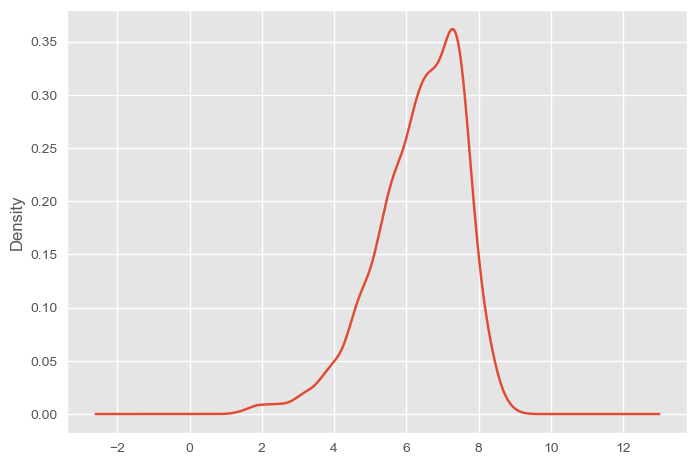

In [25]:
major_movies["rating"].plot.kde()
plt.show()

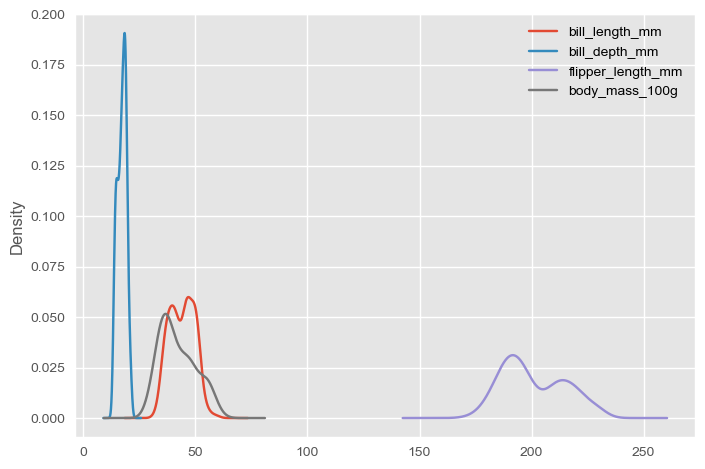

In [26]:
penguins_altered.plot.kde()
plt.show()

### Bar Chart

We'll show a bar chart for the first 10 movies

In [27]:
subset = major_movies.set_index("title")
subset = subset.iloc[0:10]
subset

,Unnamed: 0,year,length,budget,rating,votes,r1,r2,r3,r4,...,r9,r10,mpaa,Action,Animation,Comedy,Drama,Documentary,Romance,Short
title,,,,,,,,,,,,,,,,,,,,,
'A' gai waak,15,1983,106,NaN,7.1,1259,4.5,4.5,4.5,4.5,...,14.5,24.5,PG-13,1,0,1,0,0,0,0
'A' gai waak juk jaap,16,1987,101,NaN,7.2,614,4.5,4.5,4.5,4.5,...,14.5,14.5,PG-13,1,0,1,0,0,0,0
'Breaker' Morant,17,1980,107,NaN,7.9,2718,4.5,4.5,4.5,4.5,...,24.5,24.5,NaN,0,0,0,1,0,0,0
'Crocodile' Dundee II,19,1988,110,NaN,5.0,7252,4.5,4.5,4.5,14.5,...,4.5,4.5,NaN,1,0,1,0,0,0,0
'I Know Where I'm Going!',29,1945,92,NaN,7.7,825,4.5,4.5,4.5,4.5,...,14.5,34.5,NaN,0,0,0,1,0,1,0
'Manos' the Hands of Fate,35,1966,74,19000.0,1.6,7996,74.5,4.5,4.5,4.5,...,4.5,14.5,NaN,0,0,0,0,0,0,0
'Round Midnight,44,1986,133,NaN,7.3,902,4.5,4.5,4.5,4.5,...,14.5,24.5,NaN,0,0,0,1,0,0,0
'Til There Was You,48,1997,113,23000000.0,4.8,799,4.5,4.5,4.5,14.5,...,4.5,14.5,PG-13,0,0,1,0,0,1,0
"'burbs, The",51,1989,101,NaN,6.0,7641,4.5,4.5,4.5,4.5,...,4.5,14.5,NaN,0,0,1,0,0,0,0


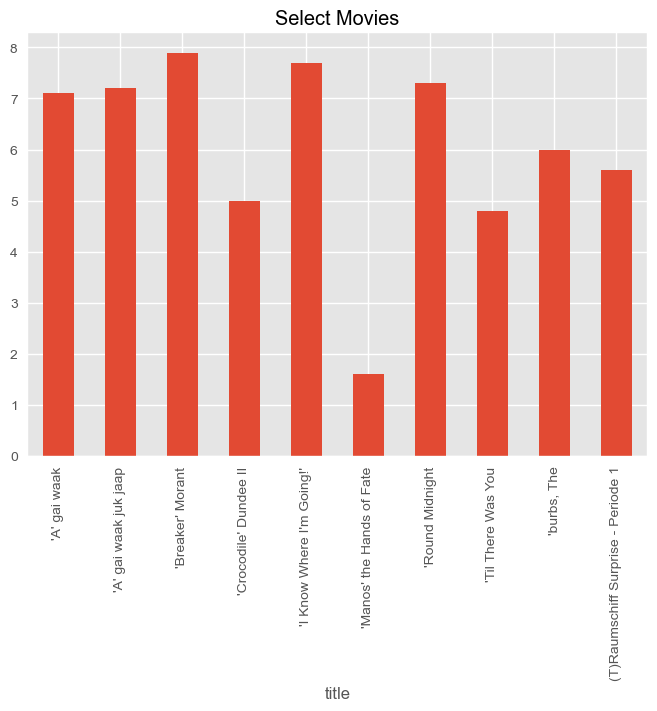

In [28]:
subset["rating"].plot(kind="bar", title="Select Movies")
plt.show()

This seems hard to read. What if we rotate it?

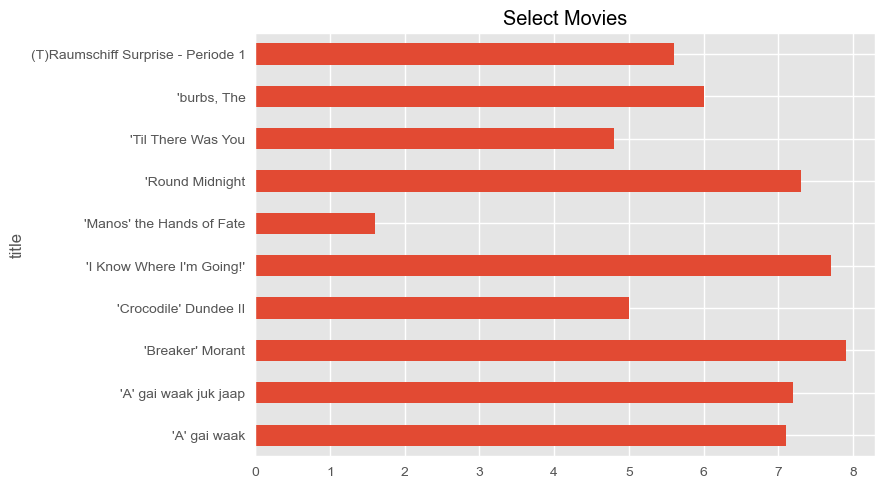

In [29]:
subset["rating"].plot(kind="barh", title="Select Movies")
plt.show()

Now the labels are so much easier to read!

We can also create grouped bar charts. The values should be on the same scale.

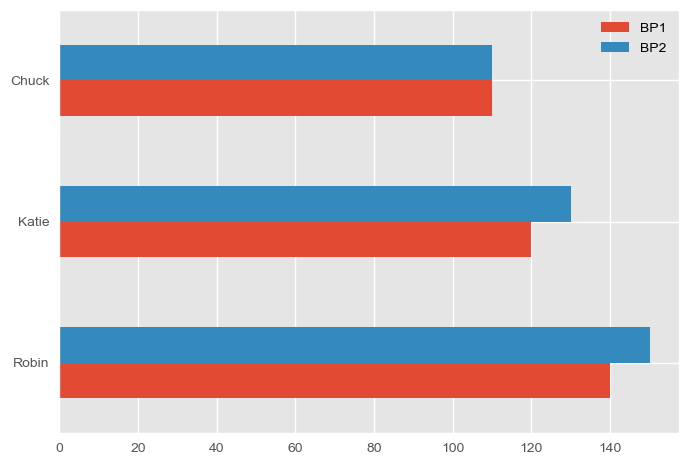

In [30]:
pulse = pd.DataFrame({
        "BP1":[140, 120, 110],
        "BP2":[150, 130, 110]
    })
pulse.index = ["Robin", "Katie", "Chuck"]

pulse.plot(kind="barh")
plt.show()

Equally, we can create stacked bar charts: 

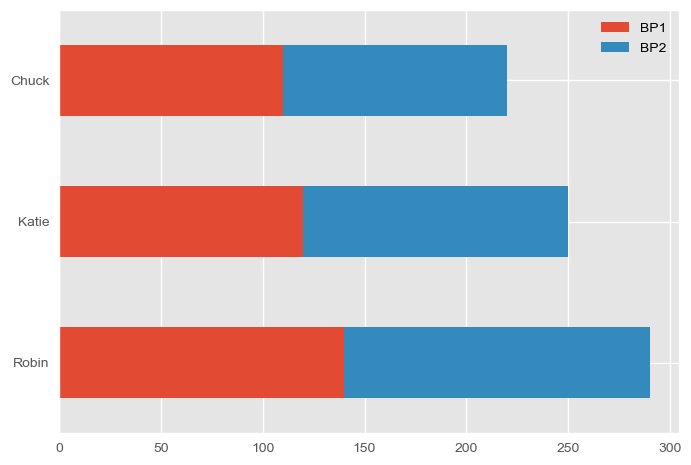

In [31]:
pulse.plot(kind="barh", stacked="True")
plt.show()

### Scatterplot

We can plot a scatterplot, comparing ratings of movies over time:

<Figure size 1000x1000 with 0 Axes>

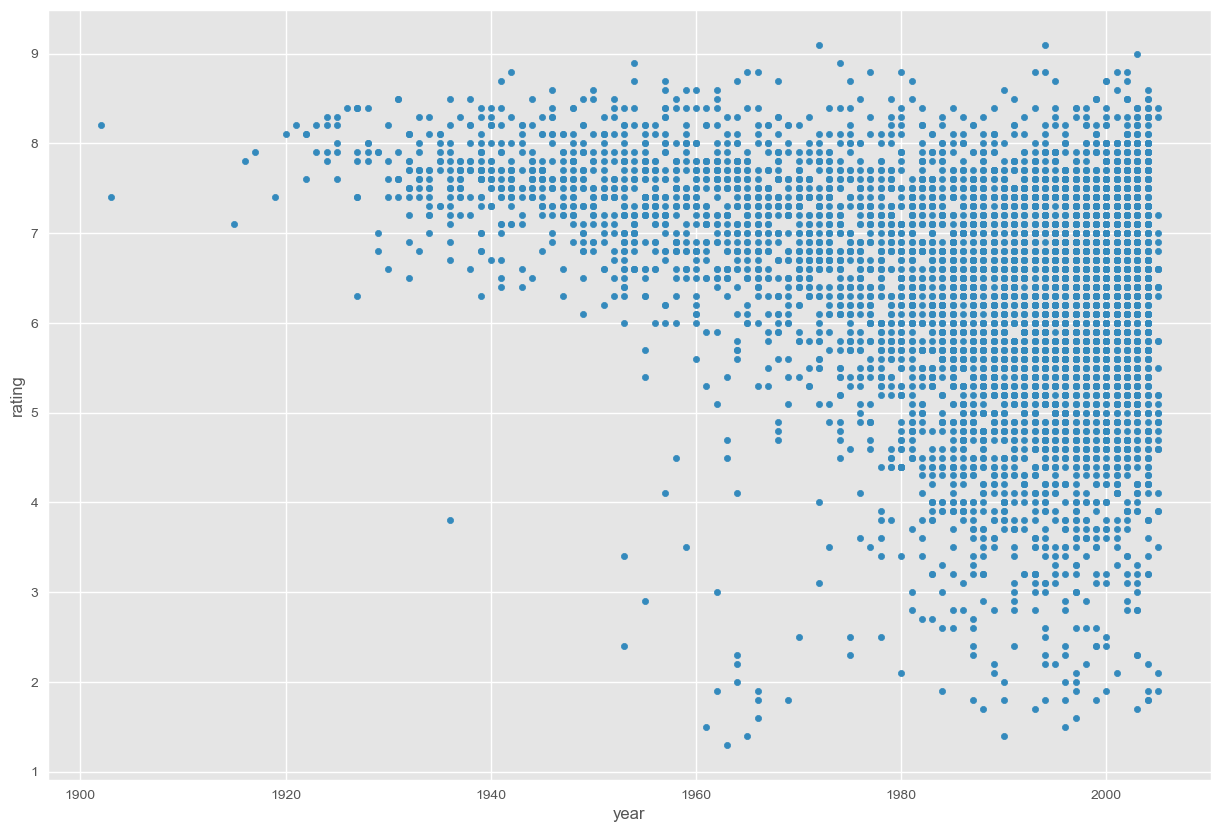

In [32]:
plt.figure(figsize=(10, 10))
major_movies.plot.scatter("year", "rating", figsize=(15, 10))
plt.show()

However, here we might overplot some points in more recent years. We can fix that with an alpha value:

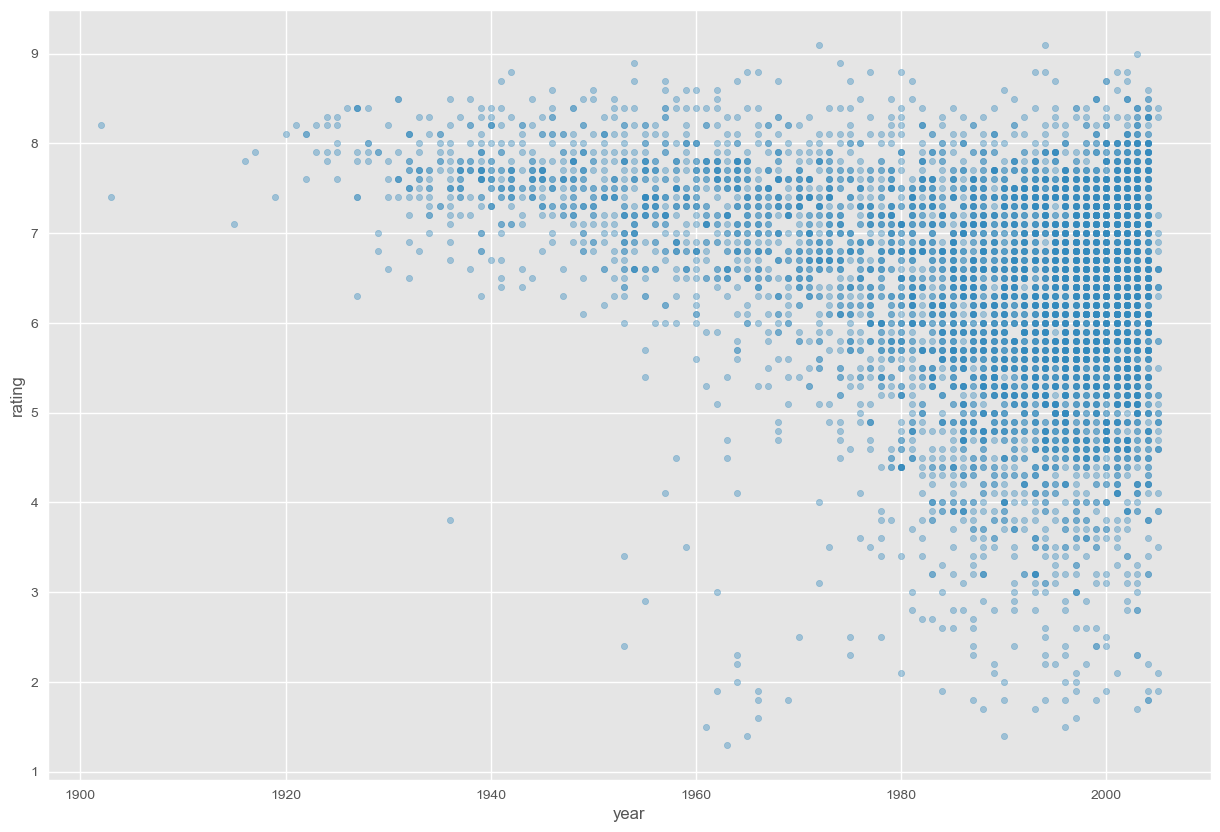

In [33]:
major_movies.plot.scatter("year", "rating", figsize=(15, 10), alpha=0.4)
plt.show()

### Box Plot

Let's plot a box plot of the ratings

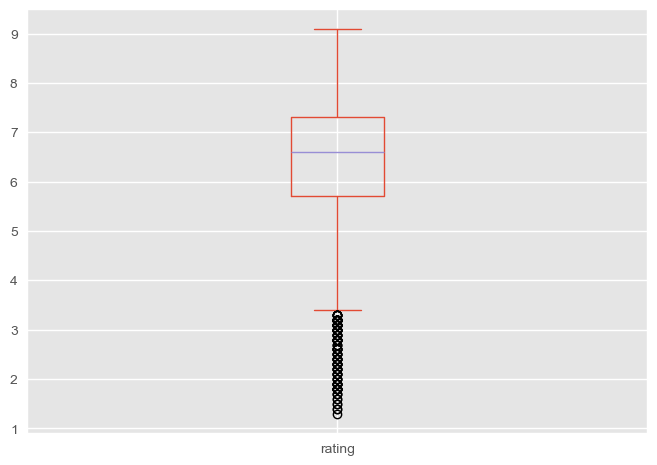

In [34]:
major_movies["rating"].plot.box()
plt.show()

We can also create boxplots for the data grouped by another column. Here, we create a rating box plot for each year: 

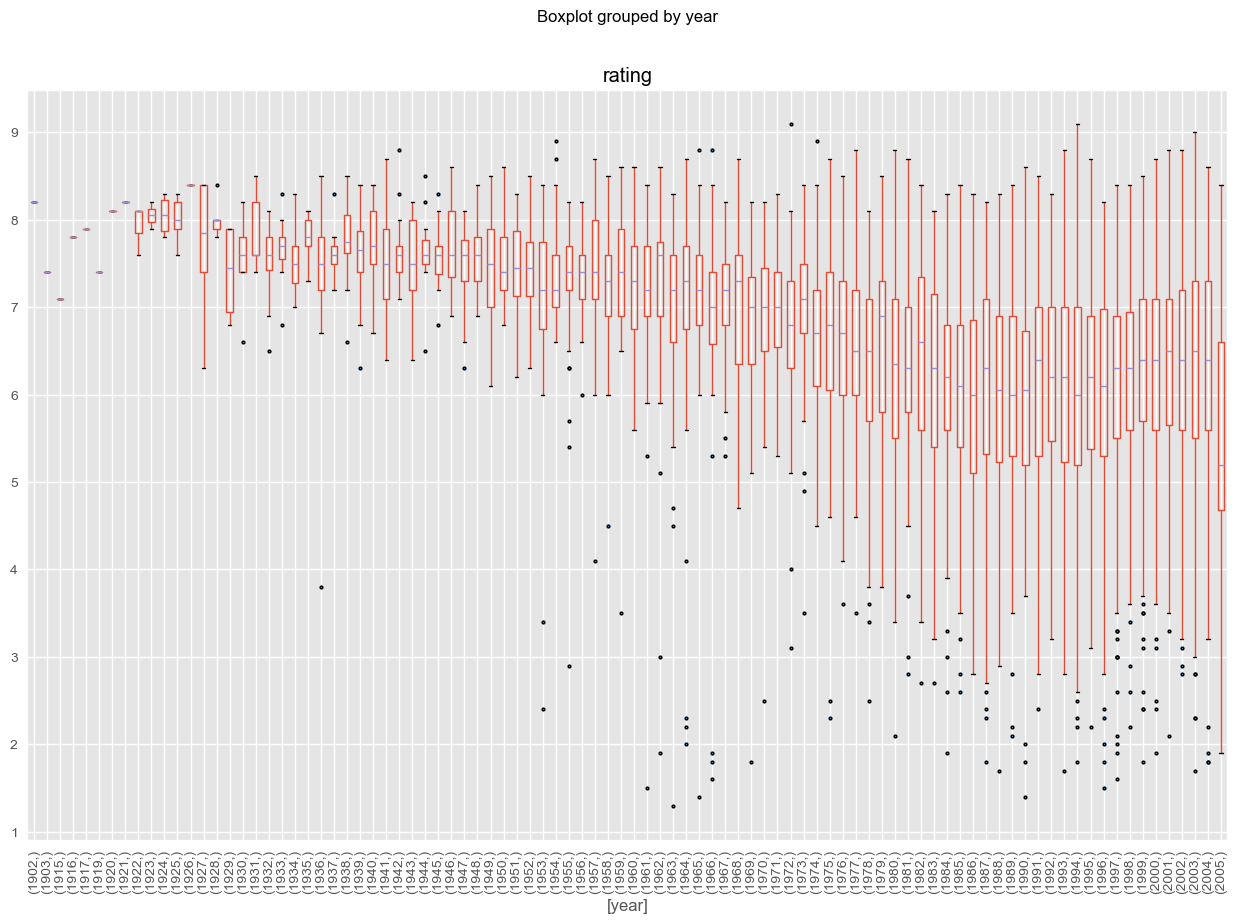

In [35]:
#this is styling information
flierprops = dict(marker='o', markerfacecolor='steelblue', markersize=2,
                  linestyle='none')
major_movies.boxplot(column=["rating"], by=["year"], rot=90, figsize=(15,10), flierprops=flierprops)
plt.show()

## Scatterplot Matrix 

We frequently will look at high-dimensional datasets. We can do that conveniently with a scatterplot matrix:

In [36]:
# import the scatter_matrix functionality
from pandas.plotting import scatter_matrix

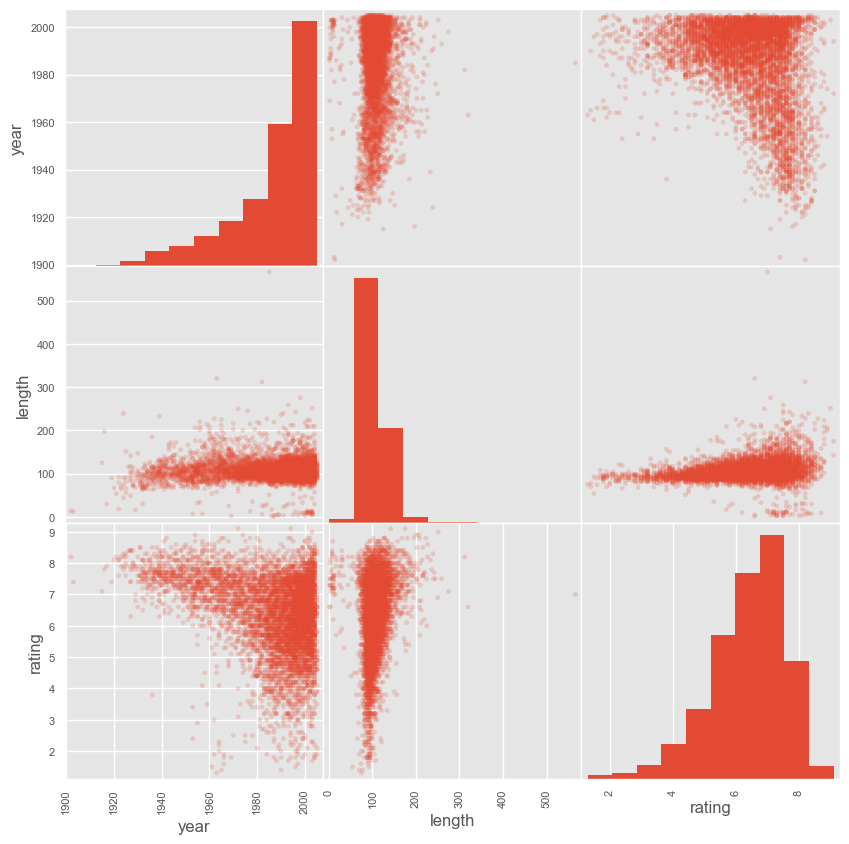

In [37]:
scatter_matrix(major_movies[["year", "length", "rating"]], alpha = 0.2, figsize=(10, 10))
plt.show()

Here the cells with the same variables in columns and rows are shown as histograms. We can also use KDEs instead: 

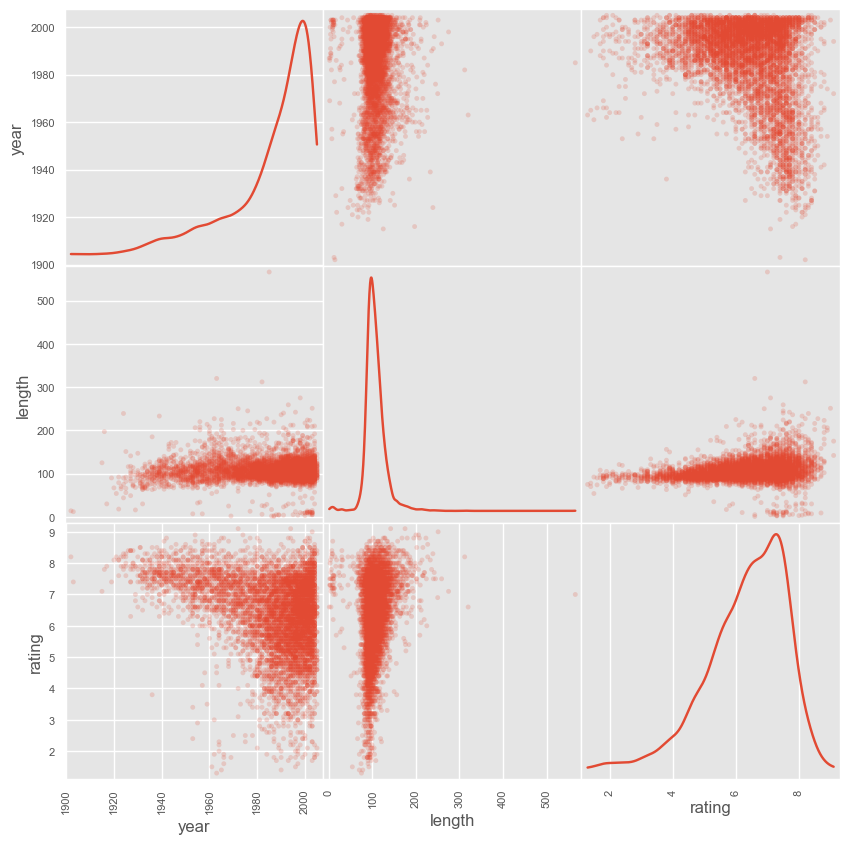

In [38]:
scatter_matrix(major_movies[["year", "length", "rating"]], diagonal="kde", alpha = 0.2, figsize=(10, 10))
plt.show()

We can also use a categorical label to color code a value. To do that, we have to create a series of the length of the dataset that defines the color for each row: 

In [39]:
color_list=penguins_altered["species"].map({"Chinstrap":"#ca0020", "Gentoo":"#0571b0", "Adelie":"#5e3c99"})
color_list.head()

0    #5e3c99
1    #5e3c99
2    #5e3c99
4    #5e3c99
5    #5e3c99
Name: species, dtype: object

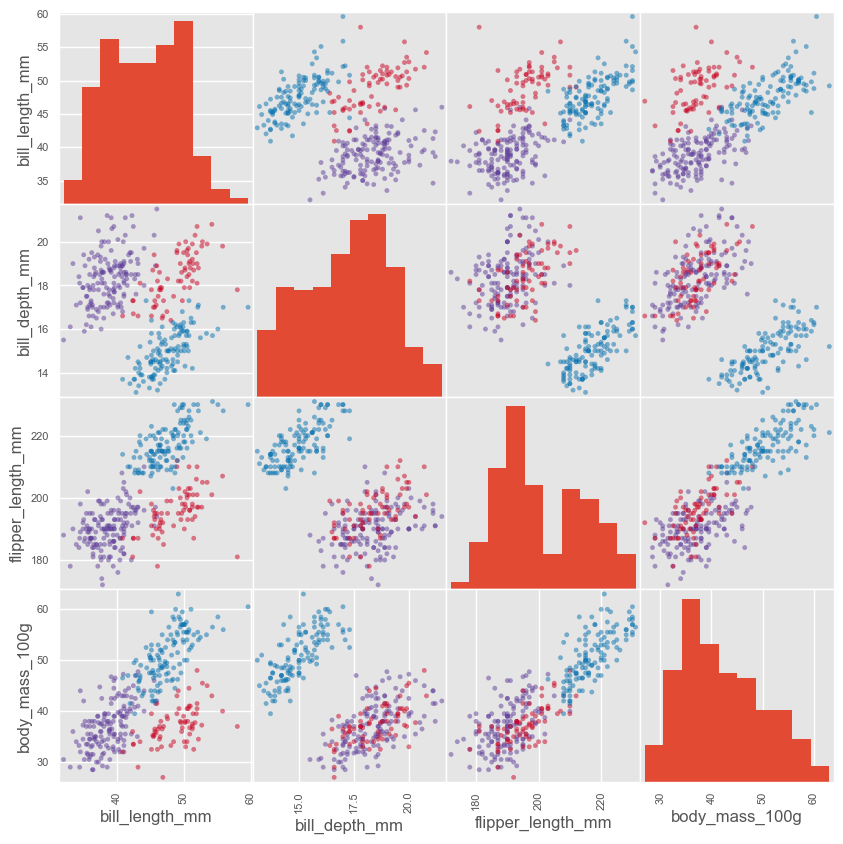

In [40]:
scatter_matrix(penguins_altered, color=color_list, figsize=(10,10))
plt.show()

#### Challenge
Can you color major_movies dataset by genre?

# Seaborn

We often have a chart in mind, and we don't have to be picky about how to achieve it in Python. [Seaborn](https://seaborn.pydata.org/introduction.html) is a good library that has a lot of very useful advanced plots built in that are tricky to re-create with Matplotlib. 


We won't cover all the plots here, just give you a flavor of what's possible. 

In [41]:
# Import seaborn
import seaborn as sns

# Apply the default theme
sns.set_theme()

# Load an example dataset into a pandas dataframe. 
tips = sns.load_dataset("tips")
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


We start off with a scatterplot, which Seaborn calls (oddly?) ["Relationship Plot"](https://seaborn.pydata.org/generated/seaborn.relplot.html#seaborn.relplot).

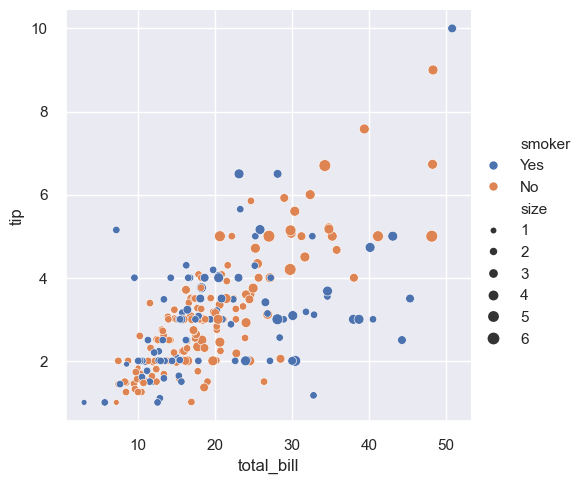

In [42]:
# Create a visualization
sns.relplot(
    data=tips,
    x="total_bill", y="tip",
    hue="smoker", size="size",
)
plt.show()

We can facet the plots by a categorical column in the dataset:

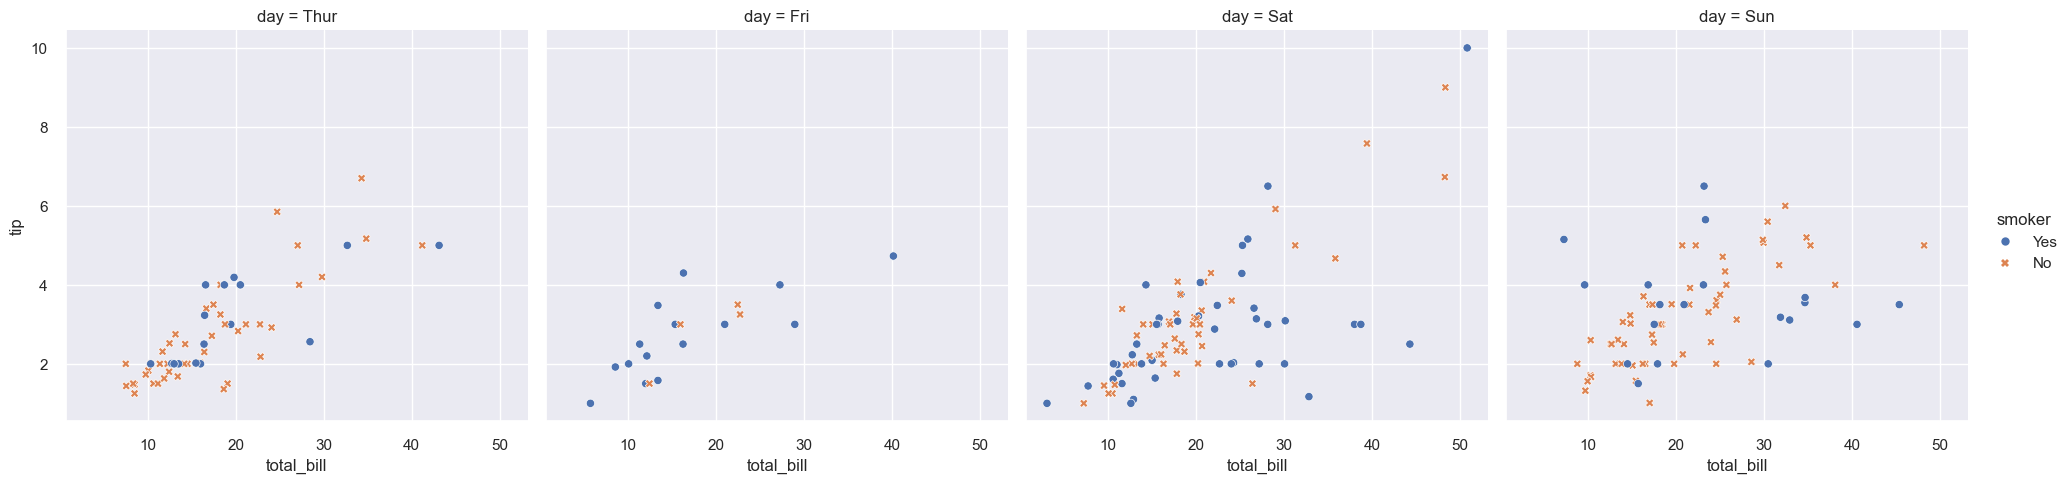

In [43]:
# Also try faceting by "time"
sns.relplot(
    data=tips,
    x="total_bill", y="tip", col="day",
    style="smoker", hue="smoker")
plt.show()

Very useful are [categorical plots](https://seaborn.pydata.org/generated/seaborn.catplot.html#seaborn.catplot). Here's a strip plot:

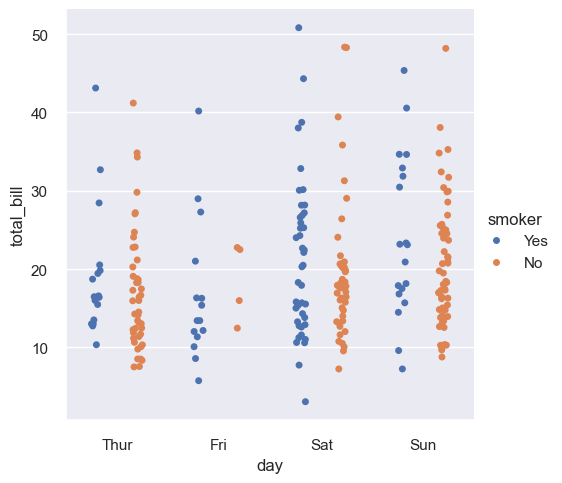

In [44]:
sns.catplot(data=tips, kind="strip", x="day", y="total_bill", hue="smoker", dodge=True)
plt.show()

And a "Beeswarm" plot, that avoids overlaps:

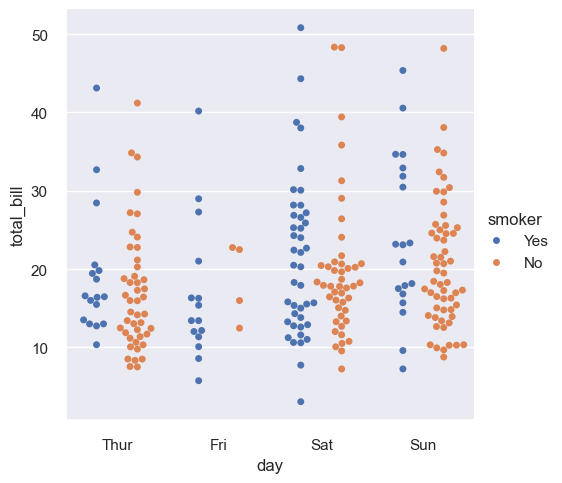

In [45]:
sns.catplot(data=tips, kind="swarm", x="day", y="total_bill", hue="smoker", dodge=True)
plt.show()

And a Violin Plot that is faceted: 

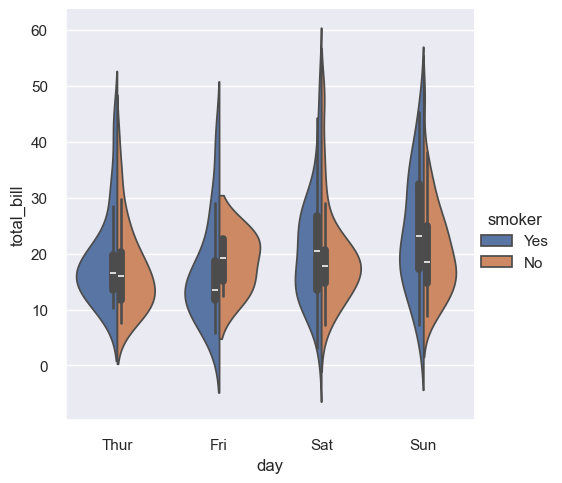

In [46]:
sns.catplot(data=tips, kind="violin", x="day", y="total_bill", hue="smoker", split=True)
plt.show()

For datasets with categories, we can use "joint plots" to get an overview of the distributions and their relationships: 

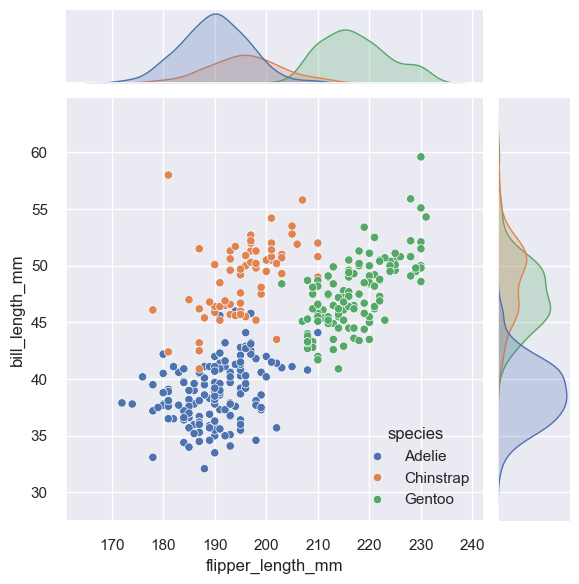

In [47]:
penguins = sns.load_dataset("penguins")
sns.jointplot(data=penguins, x="flipper_length_mm", y="bill_length_mm", hue="species")
plt.show()

And we can create [scatterplot matrices (pairplots in Seaborn)](https://seaborn.pydata.org/generated/seaborn.pairplot.html#seaborn.pairplot) to show relationships:

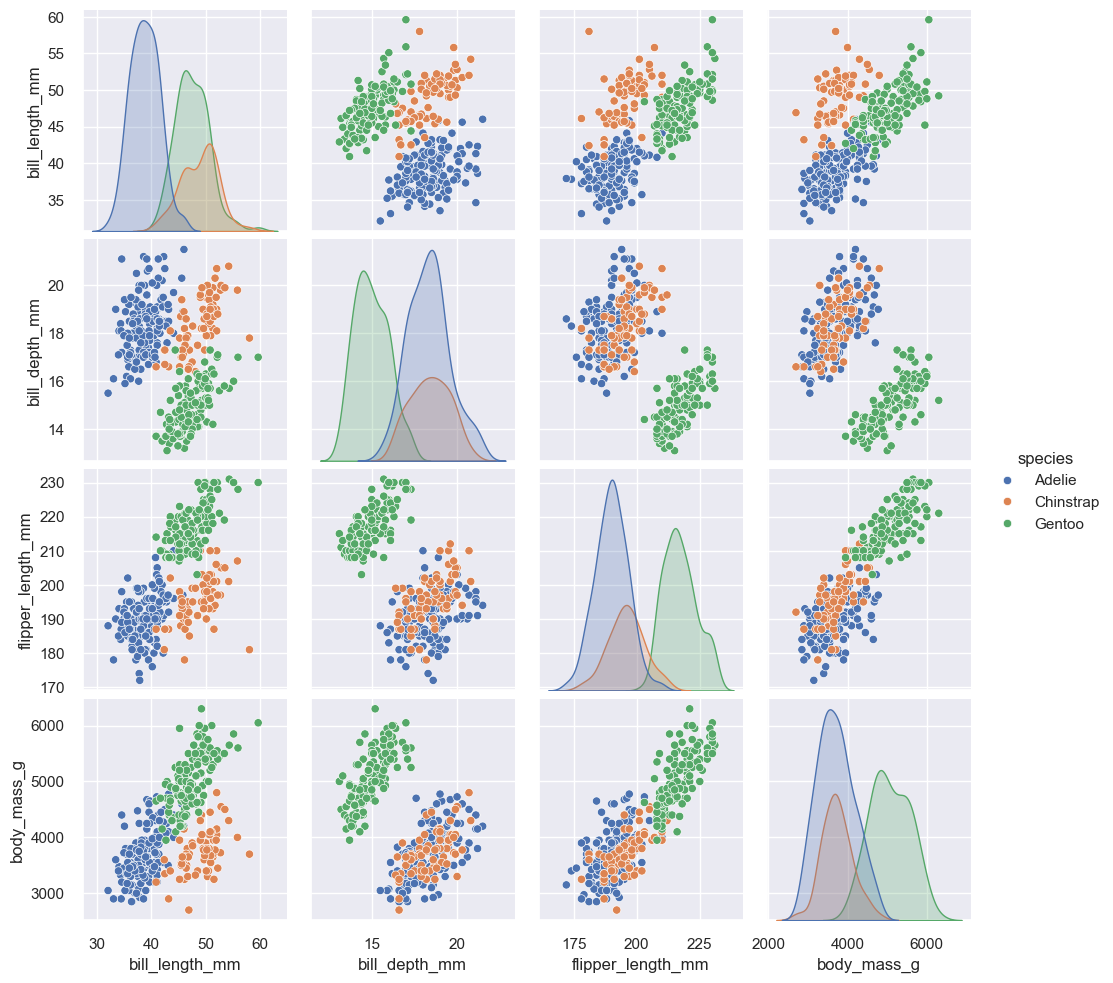

In [48]:
sns.pairplot(data=penguins, hue="species")
plt.show()

# Altair

[Altair](https://altair-viz.github.io/) is a modern plotting library based on Vega. We're not going to go into details, but we've compiled a couple of examples below. 

In contrast to Seaborn, it's not based on Matplotlib but renders directly to the web browser. 

You will likely have to install Altair: 

`
!pip install altair vega_datasets
`

In [49]:
import altair as alt

ModuleNotFoundError: No module named 'altair'

In [ ]:
movies = pd.read_csv('http://vcg.github.io/upset/data/movies/movies.csv', sep=';')
movies.head()

movies_genre = movies.copy(deep=True)
movies_genre['Genre'] = movies.loc[:,'Action':'Western'].idxmax(1)
movies_genre = movies_genre[['Name', 'Genre', 'ReleaseDate', 'AvgRating', 'Watches']]

movies_genre.head()

## Basic Charts

In [ ]:
alt.Chart(movies_genre).mark_point()

The above chart is not really useful, since it just shows all the movies on top of each other. Each row in the dataset is a `mark`.

To make this into an useful chart,  we have to encode the columns.

We will encode AvgRating along `x-axis`.

In [ ]:
alt.Chart(movies_genre).mark_point().encode(
  x='AvgRating'
)

We can use other marks like 'point'.

There are a number of available marks that you can use; some of the more common are the following:

* ``mark_point()`` 
* ``mark_circle()``
* ``mark_square()``
* ``mark_line()``
* ``mark_area()``
* ``mark_bar()``
* ``mark_tick()``

You can get a complete list of ``mark_*`` methods using Jupyter's tab-completion feature: in any cell just type:

    alt.Chart.mark_
    
Maybe a tick instead of a point is more appropriate here:

In [ ]:
alt.Chart(movies_genre).mark_tick().encode(
  x='AvgRating'
)

### Encodings

The next step is to add *visual encoding channels* (or *encodings* for short) to the chart. An encoding channel specifies how a given data column should be mapped onto the visual properties of the visualization.
Some of the more frequently used visual encodings are listed here:

* ``x``: x-axis value
* ``y``: y-axis value
* ``color``: color of the mark
* ``opacity``: transparency/opacity of the mark
* ``shape``: shape of the mark
* ``size``: size of the mark
* ``row``: row within a grid of facet plots
* ``column``: column within a grid of facet plots

For a complete list of these encodings, see the [Encodings](https://altair-viz.github.io/user_guide/encoding.html) section of the documentation.

Visual encodings can be created with the `encode()` method of the `Chart` object. 

In [ ]:
alt.Chart(movies_genre).mark_point().encode(
  y='AvgRating', size="Watches"
)

One of the central ideas of Altair is that the library will **choose good defaults for your data type**.

The basic data types supported by Altair are as follows:

<table>
  <tr>
    <th>Data Type</th>
    <th>Code</th>
    <th>Description</th>
  </tr>
  <tr>
    <td>quantitative</td>
    <td>Q</td>
    <td>Numerical quantity (real-valued)</td>
  </tr>
  <tr>
    <td>nominal</td>
    <td>N</td>
    <td>Name / Unordered categorical</td>
  </tr>
  <tr>
    <td>ordinal</td>
    <td>O</td>
    <td>Ordered categorial</td>
  </tr>
  <tr>
    <td>temporal</td>
    <td>T</td>
    <td>Date/time</td>
  </tr>
</table>

When you specify data as a pandas dataframe, these types are **automatically determined** by Altair.

We can encode another variable along Y-axis to turn it into a scatter plot.

Let us plot `ReleaseDate` on X-axis and `AvgRating` on Y-axis.

In [ ]:
alt.Chart(movies_genre).mark_point().encode(
  x = 'ReleaseDate',
  y = 'AvgRating'
)

Having axis start from 0 does not always makes sense, we can turn off this behaviour.

We will use [`altair.Scale`](https://altair-viz.github.io/user_guide/generated/core/altair.Scale.html), [altair.X](https://altair-viz.github.io/user_guide/generated/channels/altair.X.html), and [altair.Y](https://altair-viz.github.io/user_guide/generated/channels/altair.Y.html)

In [ ]:
alt.Chart(movies_genre).mark_point().encode(
  alt.X('ReleaseDate', scale = alt.Scale(zero = False)),
  alt.Y('AvgRating', scale = alt.Scale(zero = False))
)

We can replace this `point` mark with `circle`

In [ ]:
alt.Chart(movies_genre).mark_circle().encode(
  alt.X('ReleaseDate', scale = alt.Scale(zero = False)),
  alt.Y('AvgRating', scale = alt.Scale(zero = False))
)

We can encode another variable as color of the marks. We will use `Children`, `Horror`,  and `Documentary` genres only.

In [ ]:
select_genres = movies_genre[movies_genre['Genre'].isin(['Children', 'Horror', 'Documentary'])]

alt.Chart(select_genres).mark_circle().encode(
  alt.X('ReleaseDate', scale = alt.Scale(zero = False)),
  alt.Y('AvgRating', scale = alt.Scale(zero = False)),
  color='Genre'
)

We can also color using a continous variable, let us try `Watches`.

In [ ]:
alt.Chart(select_genres).mark_circle().encode(
  alt.X('ReleaseDate', scale = alt.Scale(zero = False)),
  alt.Y('AvgRating', scale = alt.Scale(zero = False)),
  color='Watches'
)

In both cases, `Altair` automatically selects proper colormaps

## Binning and Aggregation

We can bin our data and create histograms.

Altair does not have special functions to create a histogram like matplotlib.

We use `alt.X()` for the x encoding and `count()`  for y.

We will also change the `mark` type to `bar`.

In [ ]:
alt.Chart(movies_genre).mark_bar().encode(
  x = alt.X('AvgRating', bin=True),
  y = 'count()'
)

We can control the bins using `altair.Bin`

In [ ]:
alt.Chart(movies_genre).mark_bar().encode(
  x = alt.X('AvgRating', bin=alt.Bin(maxbins = 5)),
  y = 'count()',
)

The data will be automatically grouped within each bin, if we apply another encoding e.g. `color`.

In [ ]:
alt.Chart(select_genres).mark_bar().encode(
  x = alt.X('AvgRating', bin=alt.Bin(maxbins = 5)),
  y = 'count()',
  color = 'Genre'
)

We can make a seperate plot for each category if we use `column` encoding.

In [ ]:
alt.Chart(select_genres).mark_bar().encode(
  x = alt.X('AvgRating', bin=alt.Bin(maxbins = 5)),
  y = 'count()',
  color = 'Genre',
  column = 'Genre'
)

## Line Chart

We will plot mean average rating for each year.



In [ ]:
alt.Chart(movies_genre).mark_line().encode(
  x = 'ReleaseDate',
  y = alt.X('mean(AvgRating)', scale=alt.Scale(zero=False))
)

## Compound Charts

When we want to use [compound charts], Altair has a special syntax for that. First we define two charts, hist and scatter:

In [ ]:
hist = alt.Chart(select_genres).mark_bar().encode(
  x = 'count()',
  y = 'Genre',
  color = 'Genre'
).properties(
  width = 400,
  height = 100
)

scatter = alt.Chart(select_genres).mark_circle().encode(
  alt.X('ReleaseDate', scale = alt.Scale(zero = False)),
  alt.Y('AvgRating', scale = alt.Scale(zero = False)),
  color='Genre'
)

Then we can call the `vconcat` (vertical concatenation) function:

In [ ]:
alt.vconcat(hist, scatter)

Alternatively, we can use the `&` operator, which is overloaded to do `vconcat`: 

In [ ]:
hist & scatter

If we want horizontal concatenation, we can do this with `hconcat` or the `|` operator.

In [ ]:
scatter | hist 

Finally, we can layer two charts on top of each other, using the `layer()` function or the `+` operator. 

In [ ]:
year_hist = alt.Chart(select_genres).mark_bar().encode(
  x = 'ReleaseDate',
  y = 'count()'
).properties(
  width = 400,
  height = 300
)

(year_hist + scatter).resolve_scale(
    y = 'independent'
)

## Interactions

We can add simple interactions using the `interactive` function.

This enables simple interactions like zooming and panning.

In [ ]:
alt.Chart(movies_genre).mark_circle().encode(
  alt.X('ReleaseDate', scale = alt.Scale(zero = False)),
  alt.Y('AvgRating', scale = alt.Scale(zero = False))
).interactive()

### Selections

To really look at multi-dimensional data, interactive selections based on brushes are useful. This is where Altair really shines. 

We first have to specify how we want to select something: 

In [ ]:
interval = alt.selection_interval()

alt.Chart(select_genres).mark_circle().encode(
  alt.X('ReleaseDate', scale = alt.Scale(zero = False)),
  alt.Y('AvgRating', scale = alt.Scale(zero = False)),
  color='Genre'
).add_params(interval)

Currently this selection does nothing.

We can use conditional highlighting when selection made. We use `altair.condition` and specify that elements outside the "interval" are shown in light gray.

In [ ]:
interval = alt.selection_interval()

alt.Chart(select_genres).mark_circle().encode(
  alt.X('ReleaseDate', scale = alt.Scale(zero = False)),
  alt.Y('AvgRating', scale = alt.Scale(zero = False)),
  color = alt.condition(interval, 'Genre', alt.value('lightgray'))
).add_params(interval)

The selection API automatically applies to all the compound charts, as long as they have same selection applied.

Let us see an example with two horizontally concatenated charts.

In [ ]:
interval = alt.selection_interval()

base = alt.Chart(select_genres).mark_circle().encode(
  alt.X('ReleaseDate', scale = alt.Scale(zero = False)),
  color = alt.condition(interval, 'Genre', alt.value('lightgray'))
).add_params(interval)

avg_rating = base.encode(y = alt.Y('AvgRating', scale=alt.Scale(zero=False))) 
watches =  base.encode(y = alt.Y('Watches', scale=alt.Scale(zero=False)))

avg_rating | watches 

We can combine Layering and Selection API to do complicated interactions. Let us combine the above chart with histogram which shows counts for selections using a filter with the [`transform_filter()`](https://altair-viz.github.io/user_guide/generated/toplevel/altair.Chart.html?highlight=transform_filter#altair.Chart.transform_filter) function.

In [ ]:
hist = alt.Chart(select_genres).mark_bar().encode(
  x = 'count()',
  y = 'Genre',
  color = 'Genre'
).properties(
  width = 800,
  height = 100
).transform_filter(
  interval
)

scatter = avg_rating | watches

scatter & hist

Or here a similar example with a filtered scatterplot: 

In [ ]:
watches_filtered = alt.Chart(select_genres).mark_circle().encode(
  alt.X('ReleaseDate', scale = alt.Scale(zero = False)),
    y = alt.Y('Watches', scale=alt.Scale(zero=False)),
  color = alt.condition(interval, 'Genre', alt.value('lightgray'))
).transform_filter(
  interval
)

avg_rating | watches_filtered

## Maps

Altair can also do maps, based on it's `mark_geoshape` mark. See the [source for this example](https://altair-viz.github.io/gallery/choropleth.html#gallery-choropleth).

You may need to `!pip install vega_datasets` for the dataset if you didn't install it with altair above.

In [ ]:
from vega_datasets import data

counties = alt.topo_feature(data.us_10m.url, 'counties')
source = data.unemployment.url

alt.Chart(counties).mark_geoshape().encode(
    color='rate:Q'
).transform_lookup(
    lookup='id',
    from_=alt.LookupData(source, 'id', ['rate'])
).project(
    type='albersUsa'
).properties(
    width=500,
    height=300
)